In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv('smartphoneusage.csv')

print(f"Datasetul are {df.shape[0]} randuri.")
df.head()

Datasetul are 7500 randuri.


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
print("Valori lipsa pe fiecare coloana:")
print(df.isnull().sum())

print(f"\nNumar de randuri duplicate: {df.duplicated().sum()}")

Valori lipsa pe fiecare coloana:
transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Numar de randuri duplicate: 0


In [4]:
#completarea valorilor lipsa
df['addiction_level'] = df['addiction_level'].fillna('None')

# sterg dupliate
df = df.drop_duplicates()

print("gata curatarea")

gata curatarea


C:\Users\Laura\AppData\Local\Temp\ipykernel_251268\2246057094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='addiction_level', y='social_media_hours', data=df, order=ordine, palette='Reds')


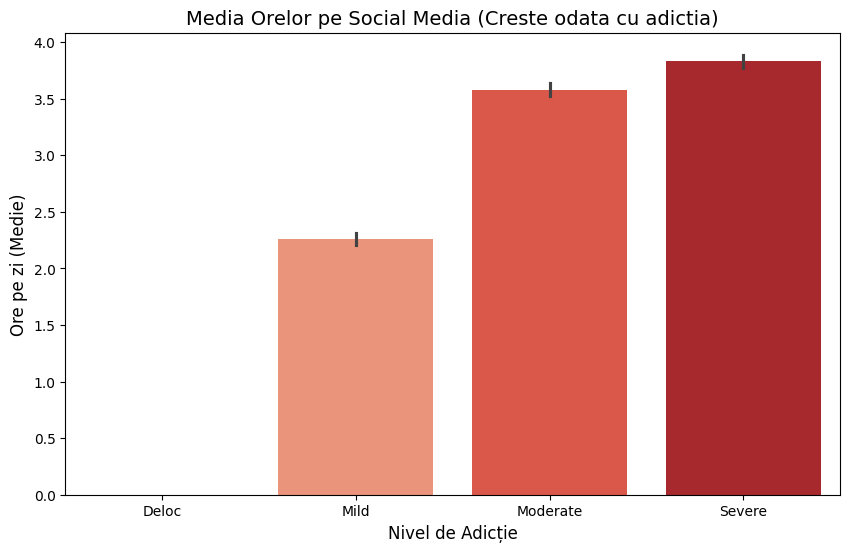

In [5]:
plt.figure(figsize=(10, 6))
# Ordonam categoriile ca sa aiba sens logic
ordine = ['Deloc', 'Mild', 'Moderate', 'Severe']

sns.barplot(x='addiction_level', y='social_media_hours', data=df, order=ordine, palette='Reds')

plt.title('Media Orelor pe Social Media (Creste odata cu adictia)', fontsize=14)
plt.xlabel('Nivel de Adicție', fontsize=12)
plt.ylabel('Ore pe zi (Medie)', fontsize=12)
plt.show()

--- Corelatia Pearson cu Addicted Label ---
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
sleep_hours                0.035496
app_opens_per_day          0.011041
gaming_hours               0.008485
age                        0.004220
work_study_hours           0.001103
notifications_per_day     -0.000660
dtype: float64

--- Importanta coloanelor (Information Gain) ---
daily_screen_time_hours    0.241182
weekend_screen_time        0.210871
social_media_hours         0.160207
work_study_hours           0.010491
notifications_per_day      0.007335
app_opens_per_day          0.002533
age                        0.000143
gaming_hours               0.000059
sleep_hours                0.000000
dtype: float64

--- Gini Index ---
social_media_hours         0.500661
daily_screen_time_hours    0.498570
weekend_screen_time        0.000769
age                        0.000000
gaming_hours               0.000000
work_study_hours           0

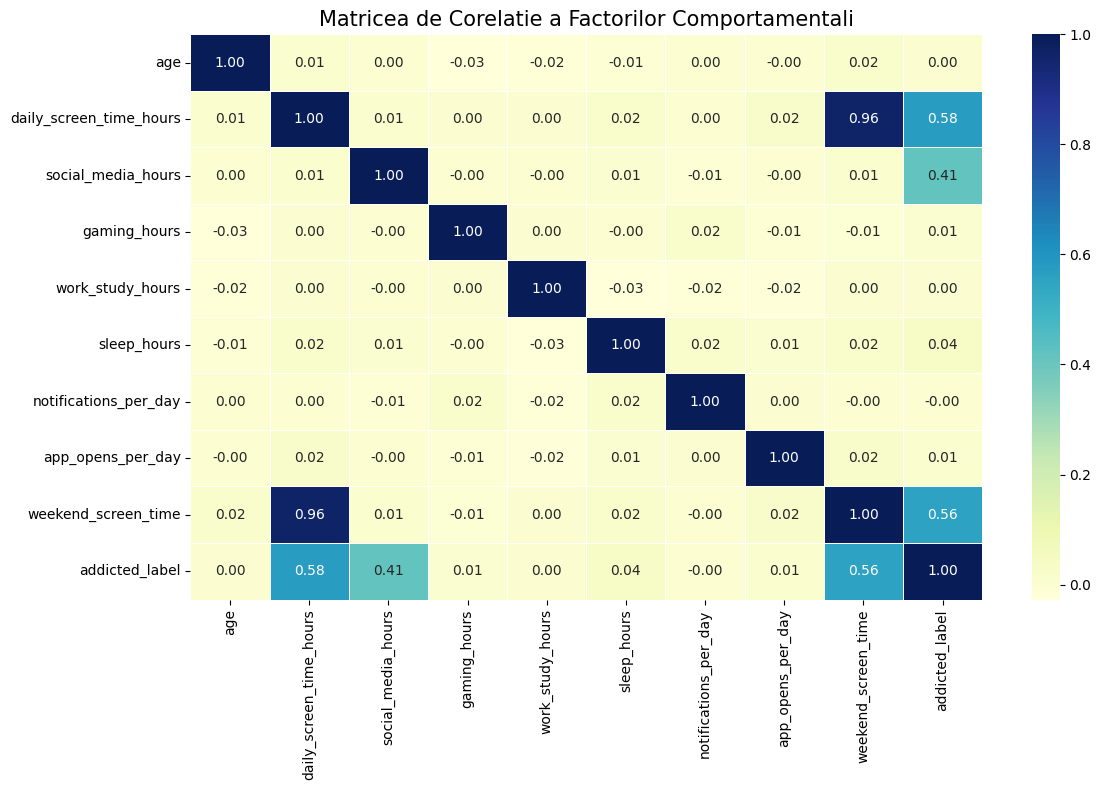

In [6]:
# 1.pregatirea datelor
coloane_de_exclus = ['addicted_label', 'user_id', 'addiction_level']
X = df.drop(columns=[c for c in coloane_de_exclus if c in df.columns], errors='ignore').select_dtypes(include=['number'])
y = df['addicted_label']

# 2. Corelatia Pearson (ne arata directia relatiei)
correlations = X.corrwith(y).sort_values(ascending=False)
print("--- Corelatia Pearson cu Addicted Label ---")
print(correlations)

# 3. Mutual Information (ne arata cat de mult ne ajuta variabila sa reducem incertitudinea)
importances = mutual_info_classif(X, y)
feature_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print("\n--- Importanta coloanelor (Information Gain) ---")
print(feature_importances)

# 4. Gini Index (cat de bine "taie" arborele datele folosind acea coloana)
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)
gini_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- Gini Index ---")
print(gini_importance)

# 5. Vizualizarea Matricei de Corelatie
plt.figure(figsize=(12, 8))
df_corr = X.copy()
df_corr['addicted_label'] = y

corr_matrix = df_corr.corr()

#heatmap-ul
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)

plt.title('Matricea de Corelatie a Factorilor Comportamentali', fontsize=15)
plt.tight_layout()
plt.show()

In [7]:
# 2. Curatare: Eliminam coloanele care nu sunt predictori comportamentali bruti
coloane_de_sters = ['addicted_label', 'user_id', 'addiction_level']
X = df.drop(columns=[c for c in coloane_de_sters if c in df.columns], errors='ignore')
y = df['addicted_label']

# 3. Encoding: Transformam variabilele text ramase (ex: Gender) in numere
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# 4. Impartim datele in Train (80%) si Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("datele sunt pregatite")

datele sunt pregatite


C:\Users\Laura\AppData\Local\Temp\ipykernel_251268\3588474599.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


In [8]:
# --- MODEL 1: Random Forest ---
param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'random_state': [42]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=3).fit(X_train, y_train)
model_rf = grid_rf.best_estimator_

# --- MODEL 2: Logistic Regression ---
param_lr = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['liblinear']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=3).fit(X_train, y_train)
model_lr = grid_lr.best_estimator_

# --- MODEL 3: Decision Tree ---
param_dt = {
    'max_depth': [3, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_dt, cv=3).fit(X_train, y_train)
model_dt = grid_dt.best_estimator_

print("Optimizarea hiperparametrilor finalizata.")

Optimizarea hiperparametrilor finalizata.


In [9]:
#predictiile pe setul de test
pred_rf = model_rf.predict(X_test)
pred_lr = model_lr.predict(X_test)
pred_dt = model_dt.predict(X_test)

#cream tabelul de rezultate
rezultate = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'Decision Tree'],
    'Acuratete': [
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt)
    ]
}).sort_values(by='Acuratete', ascending=False)

print("\nCOMPARARE REZULTATE FINALE")
print(rezultate)

print("\nCEI MAI BUNI PARAMETRI")
print(f"RF: {grid_rf.best_params_}")
print(f"LR: {grid_lr.best_params_}")
print(f"DT: {grid_dt.best_params_}")

#raportul detaliat pentru cel mai bun model
print("\nRAPORT DETALIAT PENTRU MODELUL FINAL")
print(classification_report(y_test, pred_rf))


COMPARARE REZULTATE FINALE
                 Model  Acuratete
2        Decision Tree   0.939333
0        Random Forest   0.926667
1  Logistic Regression   0.877333

CEI MAI BUNI PARAMETRI
RF: {'max_depth': None, 'n_estimators': 50, 'random_state': 42}
LR: {'C': 10.0, 'solver': 'liblinear'}
DT: {'criterion': 'gini', 'max_depth': 5}

RAPORT DETALIAT PENTRU MODELUL FINAL
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       456
           1       0.96      0.93      0.95      1044

    accuracy                           0.93      1500
   macro avg       0.91      0.92      0.91      1500
weighted avg       0.93      0.93      0.93      1500



C:\Users\Laura\AppData\Local\Temp\ipykernel_251268\629485387.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


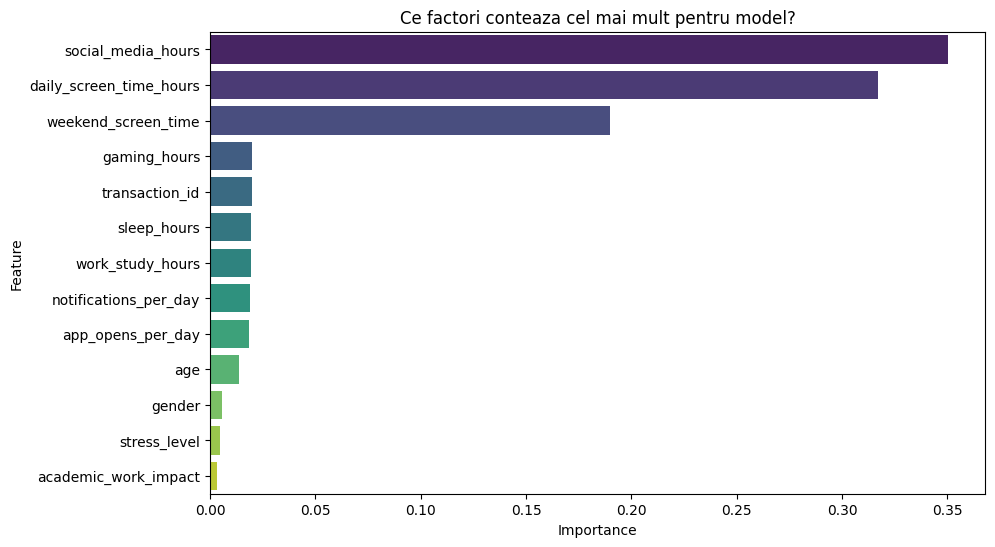

Primele 3 variabile influenteaza cel mai mult predictia adictiei


In [10]:
#Lab10 Interpretarea Modelului Final

# Extragem importanta caracteristicilor din cel mai bun model
importances = model_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Vizualizare
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Ce factori conteaza cel mai mult pentru model?')
plt.show()

print("Primele 3 variabile influenteaza cel mai mult predictia adictiei")